# Estudio de Hiperesferas: Volumen y Propiedades Geométricas en Dimensiones Altas

Thanos Drossos

Este proyecto investiga las propiedades geométricas de las esferas n-dimensionales (hiperesferas) al aumentar la dimensión. Analizamos cómo cambia el volumen total, encontrando que alcanza un máximo sorprendente alrededor de la dimensión 5.24 antes de decrecer exponencialmente. 

Examinamos también el fenómeno del "desplazamiento hacia la corteza": a medida que la dimensión aumenta, una proporción cada vez mayor del volumen se concentra en la región exterior o "corteza". En dimensiones muy altas (>100), prácticamente todo el volumen (>99%) se encuentra en esta capa exterior.

Adicionalmente, estudiamos la relación volumen-superficie, que se aproxima asintóticamente a r/n cuando n aumenta, confirmando propiedades fundamentales de la geometría en altas dimensiones.

Dimension 2:
  Total volume: 3.141593e+00
  Crust volume: 6.251769e-02
  Ratio: 0.019900 (1.9900%)

Dimension 3:
  Total volume: 4.188790e+00
  Crust volume: 1.244113e-01
  Ratio: 0.029701 (2.9701%)

Dimension 4:
  Total volume: 4.934802e+00
  Crust volume: 1.944509e-01
  Ratio: 0.039404 (3.9404%)

Dimension 5:
  Total volume: 5.263789e+00
  Crust volume: 2.579780e-01
  Ratio: 0.049010 (4.9010%)

Dimension 10:
  Total volume: 2.550164e+00
  Crust volume: 2.438414e-01
  Ratio: 0.095618 (9.5618%)

Dimension 20:
  Total volume: 2.580689e-02
  Crust volume: 4.699256e-03
  Ratio: 0.182093 (18.2093%)

Dimension 40:
  Total volume: 3.604731e-09
  Crust volume: 1.193268e-09
  Ratio: 0.331028 (33.1028%)

Dimension 50:
  Total volume: 1.730219e-13
  Crust volume: 6.834261e-14
  Ratio: 0.394994 (39.4994%)

Dimension 100:
  Total volume: 2.368202e-40
  Crust volume: 1.501364e-40
  Ratio: 0.633968 (63.3968%)

Dimension 200:
  Total volume: 5.558833e-109
  Crust volume: 4.814062e-109
  Ratio: 0.8660

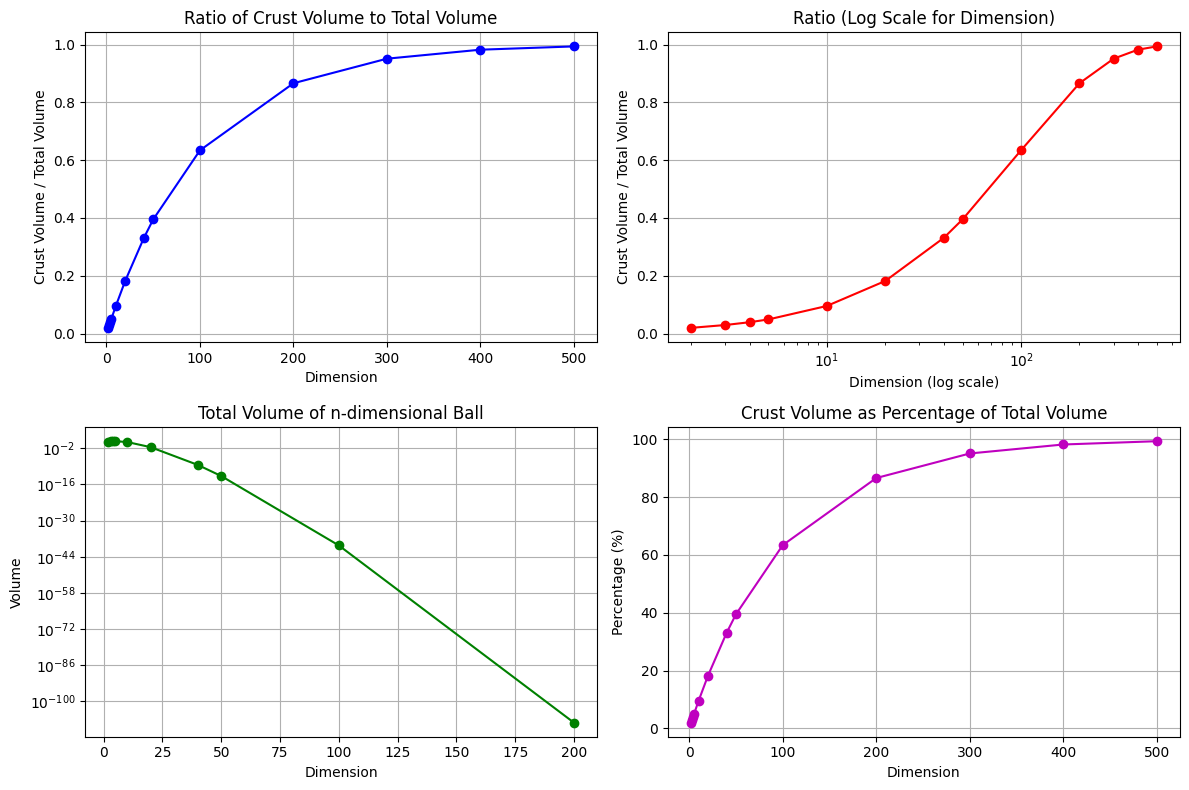

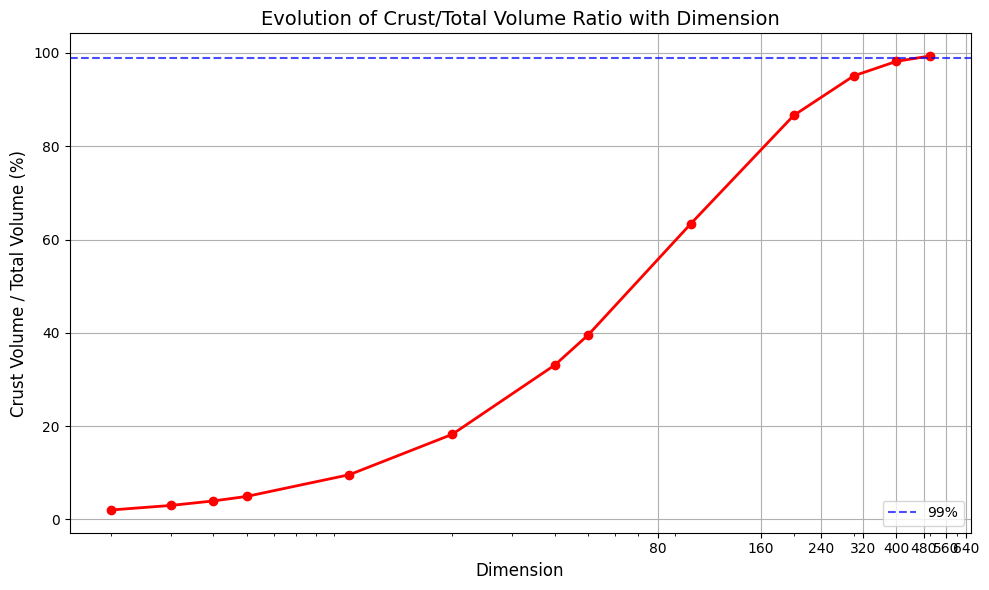

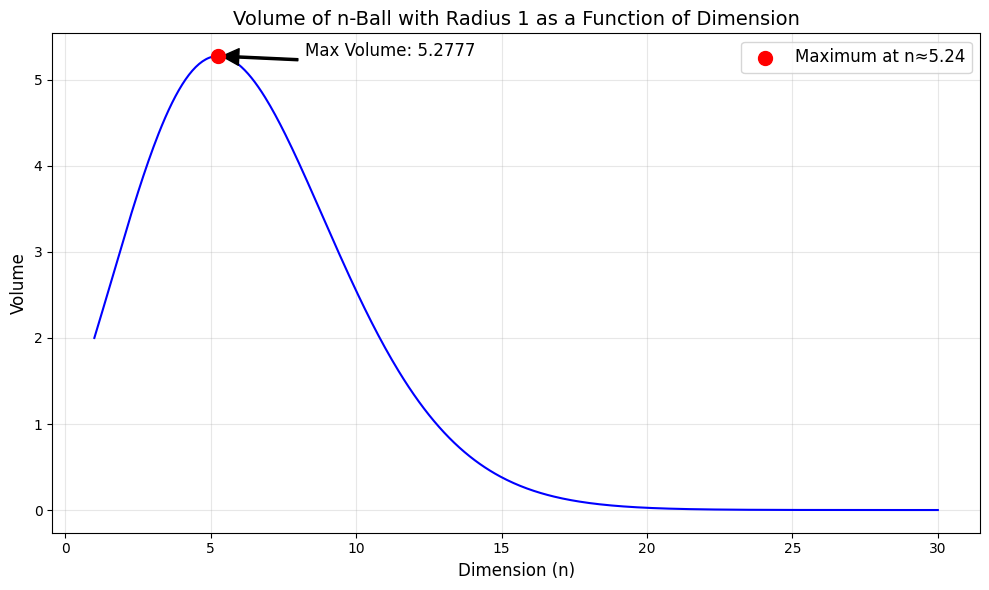

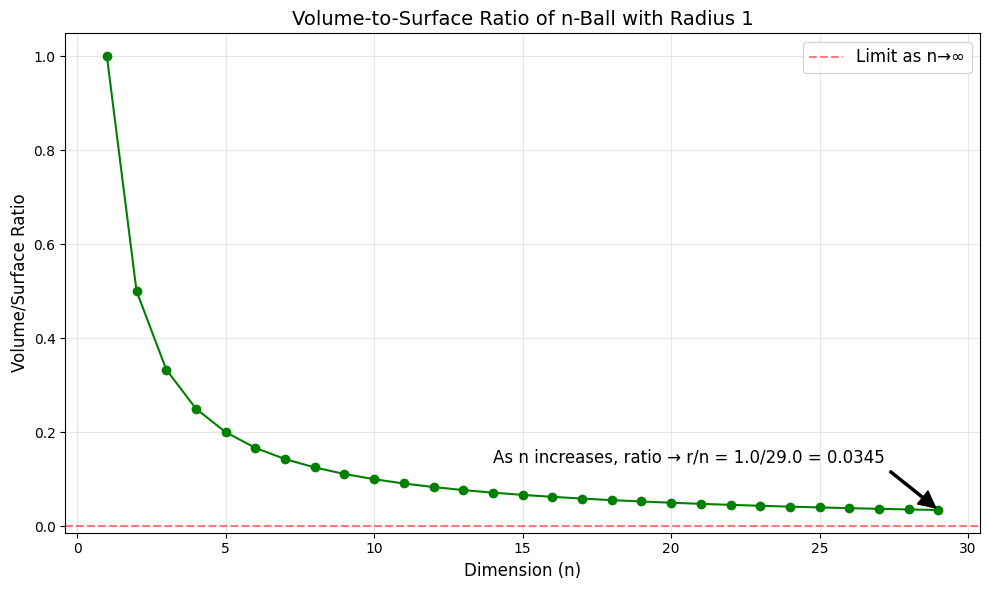

Maximum volume occurs at dimension n ≈ 5.2425
Maximum volume value: 5.277724

Volume-to-Surface ratio approaches r/n as n increases:
n = 5: Actual ratio = 0.200000, Theoretical r/n = 0.200000, Difference = -0.0000%
n = 10: Actual ratio = 0.100000, Theoretical r/n = 0.100000, Difference = 0.0000%
n = 20: Actual ratio = 0.050000, Theoretical r/n = 0.050000, Difference = -0.0000%
n = 50: Theoretical r/n = 0.020000
n = 100: Theoretical r/n = 0.010000


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma, loggamma
from matplotlib.ticker import MaxNLocator

# Function to calculate the logarithm of the volume of an n-dimensional ball with radius r
def log_n_ball_volume(n, r):
    return (n/2) * np.log(np.pi) + n * np.log(r) - loggamma(n/2 + 1)

# Calculate actual volume (may underflow for large n)
def n_ball_volume(n, r):
    return np.exp(log_n_ball_volume(n, r))

# Calculate the volume of the crust using logarithms
def crust_volume(n, r):
    outer_vol = n_ball_volume(n, r)
    inner_vol = n_ball_volume(n, 0.99 * r)
    return outer_vol - inner_vol

# More numerically stable crust ratio calculation
def crust_ratio(n, r, shell_thickness=0.01):
    # For high dimensions, the ratio approaches 1-(1-thickness)^n
    # This is more stable than calculating volumes separately
    return 1 - (1 - shell_thickness)**n

# Add these functions to your existing code
def n_ball_surface(n, r):
    """Calculate surface area of an n-dimensional ball with radius r"""
    return (2 * np.pi**(n/2) * r**(n-1)) / gamma(n/2)

# Dimensions to analyze
dimensions = [2, 3, 4, 5, 10, 20, 40, 50, 100, 200, 300, 400, 500]
radius = 1.0  # Unit ball

# Calculate volumes and ratios
volumes = []
crust_volumes = []
ratios = []

for n in dimensions:
    # For low dimensions, use direct calculation
    if n < 100:
        vol = n_ball_volume(n, radius)
        crust_vol = crust_volume(n, radius)
        ratio = crust_vol / vol
    # For high dimensions, use more stable approach
    else:
        vol = n_ball_volume(n, radius) if n < 300 else np.nan  # Still show volume when possible
        crust_vol = np.nan if n >= 300 else crust_volume(n, radius)
        ratio = crust_ratio(n, radius)  # This is stable for all dimensions
    
    volumes.append(vol)
    crust_volumes.append(crust_vol)
    ratios.append(ratio)

# Print results
for i, n in enumerate(dimensions):
    vol = volumes[i]
    crust_vol = crust_volumes[i]
    ratio = ratios[i]
    
    if np.isnan(vol) or np.isnan(crust_vol):
        print(f"Dimension {n}:")
        print(f"  Total volume: [too small for floating point]")
        print(f"  Crust volume: [too small for floating point]")
        print(f"  Ratio: {ratio:.6f} ({ratio*100:.4f}%)")
    else:
        print(f"Dimension {n}:")
        print(f"  Total volume: {vol:.6e}")
        print(f"  Crust volume: {crust_vol:.6e}")
        print(f"  Ratio: {ratio:.6f} ({ratio*100:.4f}%)")
    print()

# Plot the results
plt.figure(figsize=(12, 8))

# Plot ratio vs dimension
plt.subplot(2, 2, 1)
plt.plot(dimensions, ratios, 'bo-')
plt.xlabel('Dimension')
plt.ylabel('Crust Volume / Total Volume')
plt.title('Ratio of Crust Volume to Total Volume')
plt.grid(True)

# Log scale plot for better visualization
plt.subplot(2, 2, 2)
plt.semilogx(dimensions, ratios, 'ro-')
plt.xlabel('Dimension (log scale)')
plt.ylabel('Crust Volume / Total Volume')
plt.title('Ratio (Log Scale for Dimension)')
plt.grid(True)

# Plot total volumes
plt.subplot(2, 2, 3)
plt.plot(dimensions, volumes, 'go-')
plt.xlabel('Dimension')
plt.ylabel('Volume')
plt.title('Total Volume of n-dimensional Ball')
plt.yscale('log')
plt.grid(True)

# Plot ratio as percentage
plt.subplot(2, 2, 4)
plt.plot(dimensions, [r*100 for r in ratios], 'mo-')
plt.xlabel('Dimension')
plt.ylabel('Percentage (%)')
plt.title('Crust Volume as Percentage of Total Volume')
plt.grid(True)

plt.tight_layout()
plt.show()

# Alternative visualization focusing on the ratio
plt.figure(figsize=(10, 6))
plt.plot(dimensions, [r*100 for r in ratios], 'ro-', linewidth=2)
plt.axhline(y=99, color='blue', linestyle='--', alpha=0.7, label='99%')
plt.xlabel('Dimension', fontsize=12)
plt.ylabel('Crust Volume / Total Volume (%)', fontsize=12)
plt.title('Evolution of Crust/Total Volume Ratio with Dimension', fontsize=14)
plt.grid(True)
plt.legend()
plt.xscale('log')
plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

# After your existing code, add these new analyses:

# 1. Maximum Volume Dimension Analysis
# -----------------------------------
# Use a finer grid to find precisely where volume peaks
fine_dims = np.linspace(1, 30, 500)
fine_volumes = [n_ball_volume(n, radius) for n in fine_dims]

# Find the maximum volume and corresponding dimension
max_vol_idx = np.argmax(fine_volumes)
max_vol_dim = fine_dims[max_vol_idx]
max_vol = fine_volumes[max_vol_idx]

# Plot the volume as a function of dimension
plt.figure(figsize=(10, 6))
plt.plot(fine_dims, fine_volumes, 'b-')
plt.scatter([max_vol_dim], [max_vol], color='red', s=100, zorder=10, 
            label=f'Maximum at n≈{max_vol_dim:.2f}')
plt.grid(True, alpha=0.3)
plt.title('Volume of n-Ball with Radius 1 as a Function of Dimension', fontsize=14)
plt.xlabel('Dimension (n)', fontsize=12)
plt.ylabel('Volume', fontsize=12)
plt.legend(fontsize=12)
plt.annotate(f'Max Volume: {max_vol:.4f}', 
             xy=(max_vol_dim, max_vol),
             xytext=(max_vol_dim+3, max_vol),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
             fontsize=12)
plt.tight_layout()
plt.show()

# 2. Volume-to-Surface Ratio Analysis
# -----------------------------------
# Calculate surface area and volume-to-surface ratio for each dimension
regular_dims = np.arange(1, 30)
volumes_regular = [n_ball_volume(n, radius) for n in regular_dims]
surfaces = [n_ball_surface(n, radius) for n in regular_dims]
vol_to_surface_ratios = [v/s for v, s in zip(volumes_regular, surfaces)]

# Plot volume-to-surface ratio
plt.figure(figsize=(10, 6))
plt.plot(regular_dims, vol_to_surface_ratios, 'g-o', markersize=6)
plt.grid(True, alpha=0.3)
plt.title('Volume-to-Surface Ratio of n-Ball with Radius 1', fontsize=14)
plt.xlabel('Dimension (n)', fontsize=12)
plt.ylabel('Volume/Surface Ratio', fontsize=12)

# Add observation about the ratio
plt.annotate(f'As n increases, ratio → r/n = {radius}/{regular_dims[-1]:.1f} = {radius/regular_dims[-1]:.4f}',
             xy=(regular_dims[-1], vol_to_surface_ratios[-1]),
             xytext=(regular_dims[-1]-15, vol_to_surface_ratios[-1]+0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
             fontsize=12)

# Add the theoretical limit line
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Limit as n→∞')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Print the maximum volume dimension
print(f"Maximum volume occurs at dimension n ≈ {max_vol_dim:.4f}")
print(f"Maximum volume value: {max_vol:.6f}")
print("\nVolume-to-Surface ratio approaches r/n as n increases:")
for n in [5, 10, 20, 50, 100]:
    if n < 30:
        actual_ratio = vol_to_surface_ratios[n-1]
        theoretical = radius/n
        print(f"n = {n}: Actual ratio = {actual_ratio:.6f}, Theoretical r/n = {theoretical:.6f}, Difference = {(actual_ratio-theoretical)*100:.4f}%")
    else:
        theoretical = radius/n
        print(f"n = {n}: Theoretical r/n = {theoretical:.6f}")